# 🧠 Tutorial: Redes Neuronales para Recomendaciones

## Objetivo del Tutorial
Aprender **cómo funciona una red neuronal para sistemas de recomendación** usando el dataset de Amazon Fashion.

### ¿Qué aprenderás?
1. 📊 **Cómo se representan usuarios y productos** (embeddings)
2. 🧠 **Arquitectura de Neural Collaborative Filtering (NCF)**
3. 🏋️ **Cómo entrenar la red neuronal**
4. 📈 **Evaluar y visualizar resultados**
5. 🎯 **Hacer predicciones de ratings**

### Dataset
- **5,000 reviews** de productos de moda
- **200 usuarios** × **500 productos**
- Ratings: 1.0 - 5.0 ⭐

---
## 📦 Paso 1: Importar Librerías

In [2]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch para Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn para split train/test
from sklearn.model_selection import train_test_split

# Agregar path del proyecto
sys.path.append('..')
import config

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas")
print(f"PyTorch version: {torch.__version__}")
print(f"Dispositivo: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Librerías importadas
PyTorch version: 2.10.0+cpu
Dispositivo: CPU


---
## 📊 Paso 2: Cargar y Explorar Dataset

Primero entendamos qué datos tenemos.

In [3]:
# Cargar datos (formato JSON Lines)
data_list = []
with open(str(config.DATASET_FILE), 'r') as f:
    for line in f:
        data_list.append(json.loads(line.strip()))

# Convertir a DataFrame
df = pd.DataFrame(data_list)
df = df.rename(columns={
    'reviewerID': 'user_id',
    'asin': 'product_id',
    'overall': 'rating'
})

print(f"📊 Dataset cargado: {len(df):,} interacciones")
print(f"\n🧑 Usuarios únicos: {df['user_id'].nunique()}")
print(f"👕 Productos únicos: {df['product_id'].nunique()}")
print(f"⭐ Rating promedio: {df['rating'].mean():.2f}")
print(f"⭐ Rating min/max: {df['rating'].min():.1f} - {df['rating'].max():.1f}")

# Mostrar primeras filas
df[['user_id', 'product_id', 'rating']].head()

📊 Dataset cargado: 5,000 interacciones

🧑 Usuarios únicos: 200
👕 Productos únicos: 500
⭐ Rating promedio: 3.00
⭐ Rating min/max: 1.0 - 5.0


,user_id,product_id,rating
0,user_00038,B652070932,1.1
1,user_00110,B414797776,1.2
2,user_00091,B389854268,3.7
3,user_00090,B765055833,3.2
4,user_00158,B161073976,1.6


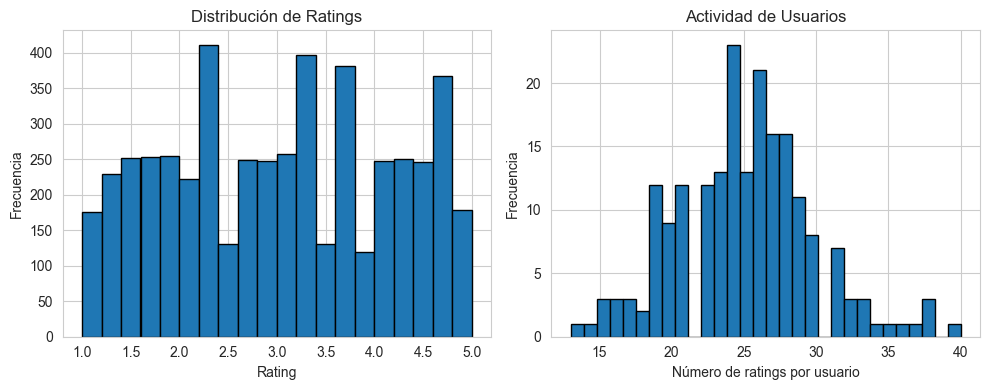

📊 Usuario más activo: 40 ratings
📊 Usuario menos activo: 13 ratings


In [4]:
# Visualizar distribución de ratings
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['rating'].hist(bins=20, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ratings')

plt.subplot(1, 2, 2)
user_counts = df.groupby('user_id').size()
user_counts.hist(bins=30, edgecolor='black')
plt.xlabel('Número de ratings por usuario')
plt.ylabel('Frecuencia')
plt.title('Actividad de Usuarios')

plt.tight_layout()
plt.show()

print(f"📊 Usuario más activo: {user_counts.max()} ratings")
print(f"📊 Usuario menos activo: {user_counts.min()} ratings")

---
## 🔢 Paso 3: Preparar Datos para la Red Neuronal

### ¿Por qué necesitamos índices?
Las redes neuronales trabajan con **números**, no con IDs de texto como `"user_00038"` o `"B652070932"`.

Creamos un **mapeo** de IDs → índices:
- `"user_00038"` → `0`
- `"user_00110"` → `1`
- etc.

In [5]:
# Obtener IDs únicos
user_ids = df['user_id'].unique()
product_ids = df['product_id'].unique()

# Crear mapeos ID → índice
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
product_to_idx = {product_id: idx for idx, product_id in enumerate(product_ids)}

# Crear mapeos inversos índice → ID (para predicciones)
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_product = {idx: product_id for product_id, idx in product_to_idx.items()}

# Aplicar mapeo al DataFrame
df['user_idx'] = df['user_id'].map(user_to_idx)
df['product_idx'] = df['product_id'].map(product_to_idx)

n_users = len(user_ids)
n_products = len(product_ids)

print(f"✅ Mapeo completado:")
print(f"   🧑 {n_users} usuarios → índices 0-{n_users-1}")
print(f"   👕 {n_products} productos → índices 0-{n_products-1}")

# Ejemplo del mapeo
print(f"\n📝 Ejemplo:")
sample = df.iloc[0]
print(f"   ID original: {sample['user_id']} + {sample['product_id']}")
print(f"   Índices:     {sample['user_idx']} + {sample['product_idx']}")
print(f"   Rating:      {sample['rating']}")

✅ Mapeo completado:
   🧑 200 usuarios → índices 0-199
   👕 500 productos → índices 0-499

📝 Ejemplo:
   ID original: user_00038 + B652070932
   Índices:     0 + 0
   Rating:      1.1


### Dividir en Train/Test
80% para entrenar, 20% para evaluar

In [6]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"📊 Split de datos:")
print(f"   🏋️ Train: {len(train_df):,} interacciones ({len(train_df)/len(df)*100:.1f}%)")
print(f"   🧪 Test:  {len(test_df):,} interacciones ({len(test_df)/len(df)*100:.1f}%)")

📊 Split de datos:
   🏋️ Train: 4,000 interacciones (80.0%)
   🧪 Test:  1,000 interacciones (20.0%)


---
## 🧠 Paso 4: Arquitectura de la Red Neuronal (NCF)

### ¿Qué es Neural Collaborative Filtering?

Es una red neuronal que aprende a predecir **qué rating daría un usuario a un producto**.

#### Componentes:

1. **Embeddings** 🎯
   - Cada usuario/producto se representa como un vector de números
   - Similar a Word2Vec pero para usuarios/productos
   - Dimensión: 64 números por usuario/producto

2. **MLP (Multi-Layer Perceptron)** 🔗
   - Capas ocultas: [128 → 64 → 32 → 1]
   - Aprende patrones complejos de las interacciones

3. **Output** 📤
   - Predicción del rating (1.0 - 5.0)

```
Usuario → Embedding (64) ──┐
                           ├─→ Concatenar (128) → MLP [128→64→32→1] → Rating
Producto → Embedding (64) ─┘
```

In [7]:
class NCFDataset(Dataset):
    """Dataset personalizado para PyTorch"""
    def __init__(self, user_indices, product_indices, ratings):
        self.users = torch.LongTensor(user_indices)
        self.products = torch.LongTensor(product_indices)
        self.ratings = torch.FloatTensor(ratings)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.products[idx], self.ratings[idx]


class NeuralCollaborativeFiltering(nn.Module):
    """
    Red Neuronal para Sistema de Recomendación

    Parámetros:
    - n_users: Número total de usuarios
    - n_products: Número total de productos
    - embedding_dim: Dimensión de los embeddings (ej: 64)
    - hidden_layers: Lista con tamaño de capas ocultas (ej: [128, 64, 32])
    """
    def __init__(self, n_users, n_products, embedding_dim=64, hidden_layers=[128, 64, 32]):
        super(NeuralCollaborativeFiltering, self).__init__()

        # 1. EMBEDDINGS: Representación vectorial de usuarios y productos
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.product_embedding = nn.Embedding(n_products, embedding_dim)

        # 2. MLP: Capas densas para aprender patrones
        input_dim = embedding_dim * 2  # Concatenamos user + product
        layers = []

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())  # Activación no-lineal
            layers.append(nn.Dropout(0.2))  # Prevenir overfitting
            input_dim = hidden_dim

        # 3. OUTPUT: Capa final para predecir rating
        layers.append(nn.Linear(input_dim, 1))

        self.mlp = nn.Sequential(*layers)

        # Inicializar pesos
        self._init_weights()

    def _init_weights(self):
        """Inicialización de pesos (mejora la convergencia)"""
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.product_embedding.weight, std=0.01)

        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, user_indices, product_indices):
        """
        Forward pass: Calcula la predicción

        Pasos:
        1. Obtener embeddings
        2. Concatenar embeddings
        3. Pasar por MLP
        4. Escalar a rango [1, 5]
        """
        # Paso 1: Obtener embeddings
        user_emb = self.user_embedding(user_indices)      # Shape: (batch, 64)
        product_emb = self.product_embedding(product_indices)  # Shape: (batch, 64)

        # Paso 2: Concatenar
        x = torch.cat([user_emb, product_emb], dim=-1)   # Shape: (batch, 128)

        # Paso 3: Pasar por MLP
        output = self.mlp(x)                              # Shape: (batch, 1)

        # Paso 4: Escalar a [1, 5] usando sigmoid
        output = torch.sigmoid(output) * 4 + 1            # Range: [1, 5]

        return output.squeeze()


print("✅ Clases definidas:")
print("   - NCFDataset: Maneja los datos")
print("   - NeuralCollaborativeFiltering: La red neuronal")

✅ Clases definidas:
   - NCFDataset: Maneja los datos
   - NeuralCollaborativeFiltering: La red neuronal


### Crear el Modelo

In [8]:
# Configuración
EMBEDDING_DIM = 64
HIDDEN_LAYERS = [128, 64, 32]
BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 10  # Reducido para evitar overfitting

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Crear modelo
model = NeuralCollaborativeFiltering(
    n_users=n_users,
    n_products=n_products,
    embedding_dim=EMBEDDING_DIM,
    hidden_layers=HIDDEN_LAYERS
).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())

print(f"🧠 Modelo creado:")
print(f"   - Embedding: {EMBEDDING_DIM} dimensiones")
print(f"   - Hidden layers: {HIDDEN_LAYERS}")
print(f"   - Total parámetros: {total_params:,}")
print(f"   - Dispositivo: {device}")
print(f"\n📐 Arquitectura:")
print(model)

🧠 Modelo creado:
   - Embedding: 64 dimensiones
   - Hidden layers: [128, 64, 32]
   - Total parámetros: 71,681
   - Dispositivo: cpu

📐 Arquitectura:
NeuralCollaborativeFiltering(
  (user_embedding): Embedding(200, 64)
  (product_embedding): Embedding(500, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


---
## 🏋️ Paso 5: Entrenar la Red Neuronal

### ¿Cómo aprende la red?

1. **Forward Pass**: La red predice un rating
2. **Calcular Error**: Comparar predicción vs rating real (MSE Loss)
3. **Backward Pass**: Calcular gradientes (derivadas)
4. **Update**: Ajustar pesos usando Adam optimizer
5. **Repetir** por múltiples epochs

### Métricas:
- **RMSE** (Root Mean Squared Error): Qué tan lejos están las predicciones
  - RMSE = 0 → Perfecto
  - RMSE < 1 → Muy bueno
  - RMSE > 1 → Mejorable

In [9]:
# Preparar datos
train_dataset = NCFDataset(
    train_df['user_idx'].values,
    train_df['product_idx'].values,
    train_df['rating'].values
)

test_dataset = NCFDataset(
    test_df['user_idx'].values,
    test_df['product_idx'].values,
    test_df['rating'].values
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Loss y Optimizer
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"✅ Preparación completa:")
print(f"   - Train batches: {len(train_loader)}")
print(f"   - Test batches: {len(test_loader)}")
print(f"   - Loss: MSE")
print(f"   - Optimizer: Adam (lr={LEARNING_RATE})")

✅ Preparación completa:
   - Train batches: 16
   - Test batches: 4
   - Loss: MSE
   - Optimizer: Adam (lr=0.001)


In [10]:
# Training Loop
history = {'train_loss': [], 'train_rmse': [], 'test_loss': [], 'test_rmse': []}

print("🏋️ Iniciando entrenamiento...\n")

for epoch in range(EPOCHS):
    # ========== ENTRENAMIENTO ==========
    model.train()
    train_loss = 0.0

    for users, products, ratings in train_loader:
        users = users.to(device)
        products = products.to(device)
        ratings = ratings.to(device)

        # Forward
        predictions = model(users, products)
        loss = criterion(predictions, ratings)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(users)

    train_loss /= len(train_dataset)
    train_rmse = np.sqrt(train_loss)

    # ========== EVALUACIÓN ==========
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for users, products, ratings in test_loader:
            users = users.to(device)
            products = products.to(device)
            ratings = ratings.to(device)

            predictions = model(users, products)
            loss = criterion(predictions, ratings)

            test_loss += loss.item() * len(users)

    test_loss /= len(test_dataset)
    test_rmse = np.sqrt(test_loss)

    # Guardar historia
    history['train_loss'].append(train_loss)
    history['train_rmse'].append(train_rmse)
    history['test_loss'].append(test_loss)
    history['test_rmse'].append(test_rmse)

    # Imprimir progreso
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train RMSE: {train_rmse:.4f} | "
          f"Test RMSE: {test_rmse:.4f}")

print("\n✅ Entrenamiento completado!")
print(f"\n📊 Mejor Test RMSE: {min(history['test_rmse']):.4f} (epoch {np.argmin(history['test_rmse'])+1})")

🏋️ Iniciando entrenamiento...

Epoch 01/10 | Train RMSE: 1.1415 | Test RMSE: 1.1440
Epoch 02/10 | Train RMSE: 1.1370 | Test RMSE: 1.1446
Epoch 03/10 | Train RMSE: 1.1199 | Test RMSE: 1.1558
Epoch 04/10 | Train RMSE: 1.0792 | Test RMSE: 1.2149
Epoch 05/10 | Train RMSE: 1.0525 | Test RMSE: 1.2148
Epoch 06/10 | Train RMSE: 1.0296 | Test RMSE: 1.2347
Epoch 07/10 | Train RMSE: 1.0005 | Test RMSE: 1.2560
Epoch 08/10 | Train RMSE: 0.9619 | Test RMSE: 1.2691
Epoch 09/10 | Train RMSE: 0.9027 | Test RMSE: 1.2858
Epoch 10/10 | Train RMSE: 0.8076 | Test RMSE: 1.3378

✅ Entrenamiento completado!

📊 Mejor Test RMSE: 1.1440 (epoch 1)


### Visualizar el Entrenamiento

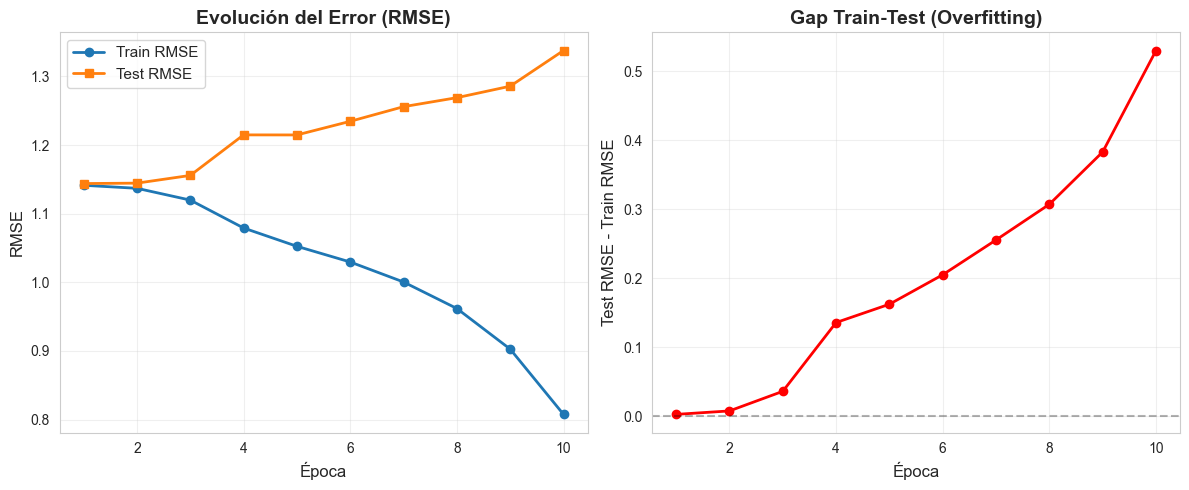

📈 Interpretación:
   ⚠️  Hay overfitting: el modelo memoriza el train set
   💡 Solución: Más dropout, menos epochs, o más datos


In [11]:
plt.figure(figsize=(12, 5))

# Gráfico 1: RMSE
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), history['train_rmse'], 'o-', label='Train RMSE', linewidth=2)
plt.plot(range(1, EPOCHS+1), history['test_rmse'], 's-', label='Test RMSE', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Evolución del Error (RMSE)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Gráfico 2: Diferencia Train-Test (detectar overfitting)
plt.subplot(1, 2, 2)
diff = np.array(history['test_rmse']) - np.array(history['train_rmse'])
plt.plot(range(1, EPOCHS+1), diff, 'o-', color='red', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Test RMSE - Train RMSE', fontsize=12)
plt.title('Gap Train-Test (Overfitting)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 Interpretación:")
if diff[-1] > 0.2:
    print("   ⚠️  Hay overfitting: el modelo memoriza el train set")
    print("   💡 Solución: Más dropout, menos epochs, o más datos")
else:
    print("   ✅ El modelo generaliza bien")

---
## 🎯 Paso 6: Hacer Predicciones

Ahora usemos el modelo entrenado para predecir ratings.

In [12]:
def predict_rating(model, user_id, product_id, user_to_idx, product_to_idx, device):
    """
    Predecir el rating que un usuario daría a un producto
    """
    # Convertir IDs a índices
    user_idx = user_to_idx[user_id]
    product_idx = product_to_idx[product_id]

    # Convertir a tensores
    user_tensor = torch.LongTensor([user_idx]).to(device)
    product_tensor = torch.LongTensor([product_idx]).to(device)

    # Predecir
    model.eval()
    with torch.no_grad():
        prediction = model(user_tensor, product_tensor)

    return prediction.item()


# Ejemplo: Predecir para 5 pares aleatorios
print("🎯 Predicciones de ejemplo:\n")
print(f"{'Usuario':<15} {'Producto':<15} {'Real':>6} {'Predicción':>11} {'Error':>6}")
print("-" * 70)

for i in range(5):
    sample = test_df.sample(1).iloc[0]
    user_id = sample['user_id']
    product_id = sample['product_id']
    real_rating = sample['rating']

    pred_rating = predict_rating(model, user_id, product_id, user_to_idx, product_to_idx, device)
    error = abs(real_rating - pred_rating)

    print(f"{user_id:<15} {product_id:<15} {real_rating:>6.2f} {pred_rating:>11.2f} {error:>6.2f}")

🎯 Predicciones de ejemplo:

Usuario         Producto          Real  Predicción  Error
----------------------------------------------------------------------
user_00108      B740389325        4.10        2.82   1.28
user_00147      B491735568        2.60        2.88   0.28
user_00055      B315984311        2.10        3.53   1.43
user_00042      B439699535        1.80        2.86   1.06
user_00039      B922308461        4.00        3.42   0.58


### Visualizar Predicciones vs Reales

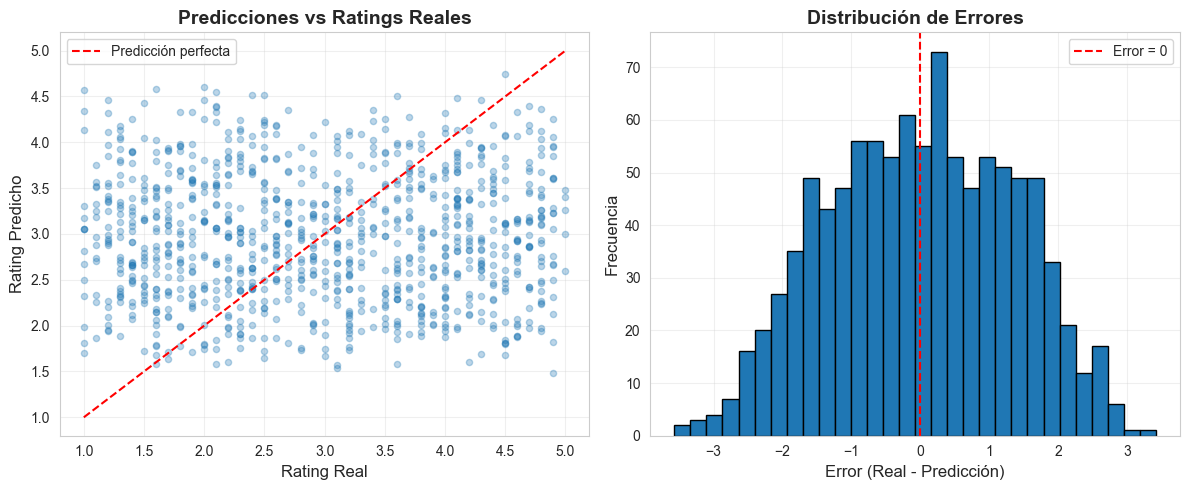

📊 Estadísticas de Error:
   - Error medio: -0.0117
   - Error absoluto medio (MAE): 1.1140
   - RMSE: 1.3378


In [13]:
# Obtener todas las predicciones del test set
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for users, products, ratings in test_loader:
        users = users.to(device)
        products = products.to(device)

        predictions = model(users, products)

        all_predictions.extend(predictions.cpu().numpy())
        all_actuals.extend(ratings.numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Visualización
plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(all_actuals, all_predictions, alpha=0.3, s=20)
plt.plot([1, 5], [1, 5], 'r--', label='Predicción perfecta')
plt.xlabel('Rating Real', fontsize=12)
plt.ylabel('Rating Predicho', fontsize=12)
plt.title('Predicciones vs Ratings Reales', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Distribución de errores
plt.subplot(1, 2, 2)
errors = all_actuals - all_predictions
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Error = 0')
plt.xlabel('Error (Real - Predicción)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Errores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Estadísticas de Error:")
print(f"   - Error medio: {np.mean(errors):.4f}")
print(f"   - Error absoluto medio (MAE): {np.mean(np.abs(errors)):.4f}")
print(f"   - RMSE: {np.sqrt(np.mean(errors**2)):.4f}")

---
## 🔍 Paso 7: Explorar los Embeddings

Los embeddings aprenden **representaciones semánticas** de usuarios y productos.

Usuarios/productos similares tendrán embeddings cercanos.

📊 Embeddings extraídos:
   - Usuarios: (200, 64) (200 usuarios × 64 dims)
   - Productos: (500, 64) (500 productos × 64 dims)


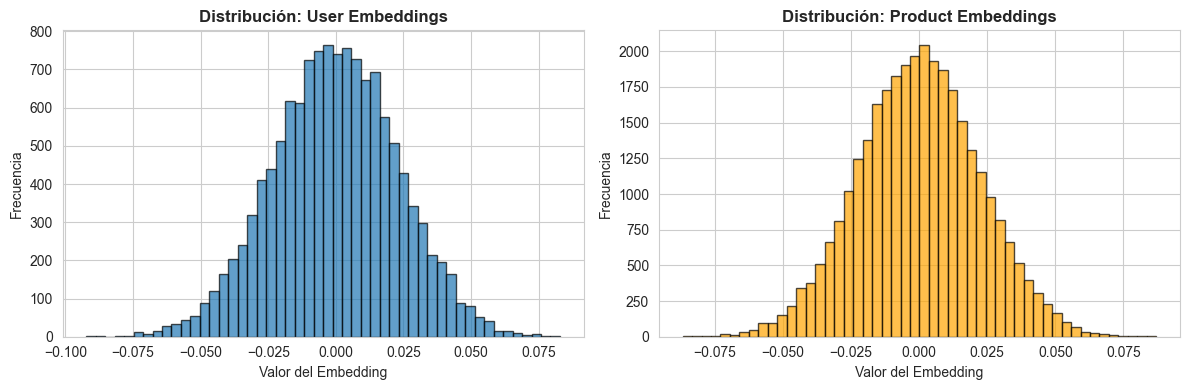

In [14]:
# Obtener embeddings
user_embeddings = model.user_embedding.weight.detach().cpu().numpy()
product_embeddings = model.product_embedding.weight.detach().cpu().numpy()

print(f"📊 Embeddings extraídos:")
print(f"   - Usuarios: {user_embeddings.shape} ({n_users} usuarios × {EMBEDDING_DIM} dims)")
print(f"   - Productos: {product_embeddings.shape} ({n_products} productos × {EMBEDDING_DIM} dims)")

# Visualizar distribución de valores
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(user_embeddings.flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Valor del Embedding')
plt.ylabel('Frecuencia')
plt.title('Distribución: User Embeddings', fontweight='bold')

plt.subplot(1, 2, 2)
plt.hist(product_embeddings.flatten(), bins=50, alpha=0.7, edgecolor='black', color='orange')
plt.xlabel('Valor del Embedding')
plt.ylabel('Frecuencia')
plt.title('Distribución: Product Embeddings', fontweight='bold')

plt.tight_layout()
plt.show()

### Encontrar Productos Similares

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_products(product_id, product_embeddings, idx_to_product, product_to_idx, top_k=5):
    """
    Encontrar productos similares usando similitud de coseno en embeddings
    """
    # Obtener índice del producto
    product_idx = product_to_idx[product_id]

    # Calcular similitud con todos los productos
    product_vec = product_embeddings[product_idx].reshape(1, -1)
    similarities = cosine_similarity(product_vec, product_embeddings)[0]

    # Obtener top-k (excluyendo el mismo producto)
    similar_indices = np.argsort(similarities)[::-1][1:top_k+1]

    return [(idx_to_product[idx], similarities[idx]) for idx in similar_indices]


# Ejemplo: Productos similares
sample_product = product_ids[0]
similar_products = find_similar_products(
    sample_product,
    product_embeddings,
    idx_to_product,
    product_to_idx,
    top_k=5
)

print(f"🔍 Productos similares a: {sample_product}\n")
for i, (prod_id, similarity) in enumerate(similar_products, 1):
    print(f"{i}. {prod_id:<15} (similitud: {similarity:.4f})")

🔍 Productos similares a: B652070932

1. B383450553      (similitud: 0.5255)
2. B771410971      (similitud: 0.5161)
3. B800235246      (similitud: 0.5101)
4. B162959284      (similitud: 0.4971)
5. B160062915      (similitud: 0.4889)


---
## 💾 Paso 8: Guardar el Modelo

Guarda el modelo y los mapeos para usarlo después.

In [16]:
# Guardar modelo y configuración
model_path = config.MODELS_DIR / 'ncf_tutorial_model.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'n_users': n_users,
    'n_products': n_products,
    'embedding_dim': EMBEDDING_DIM,
    'hidden_layers': HIDDEN_LAYERS,
    'user_to_idx': user_to_idx,
    'product_to_idx': product_to_idx,
    'idx_to_user': idx_to_user,
    'idx_to_product': idx_to_product,
    'history': history,
    'best_test_rmse': min(history['test_rmse'])
}, str(model_path))

print(f"✅ Modelo guardado en: {model_path.name}")
print(f"\n📊 Métricas finales:")
print(f"   - Mejor Test RMSE: {min(history['test_rmse']):.4f}")
print(f"   - Parámetros totales: {total_params:,}")

✅ Modelo guardado en: ncf_tutorial_model.pth

📊 Métricas finales:
   - Mejor Test RMSE: 1.1440
   - Parámetros totales: 71,681


---
## 📚 Resumen y Conclusiones

### ✅ Qué aprendiste:

1. **Embeddings**: Representación vectorial de usuarios/productos
2. **NCF Architecture**: Embeddings + MLP para predicciones
3. **Training Loop**: Forward → Loss → Backward → Update
4. **Evaluation**: RMSE, visualizaciones, detección de overfitting
5. **Predictions**: Uso del modelo para recomendar

### 🎯 Conceptos Clave:

- **Embeddings**: Capturan similitud semántica
- **MLP**: Aprende patrones complejos de interacción
- **Overfitting**: Memorizar train vs. generalizar
- **RMSE**: Métrica de error (más bajo = mejor)

### 🚀 Próximos Pasos:

1. **Experimentar con hiperparámetros**:
   - Cambiar `EMBEDDING_DIM` (32, 64, 128)
   - Modificar `HIDDEN_LAYERS` ([256, 128, 64])
   - Ajustar `LEARNING_RATE`

2. **Mejorar el modelo**:
   - Early stopping
   - Más regularización (dropout, weight decay)
   - Attention mechanism

3. **Análisis avanzado**:
   - Visualizar embeddings con t-SNE
   - Explicabilidad de recomendaciones
   - A/B testing

### 📖 Recursos:

- [Neural Collaborative Filtering Paper](https://arxiv.org/abs/1708.05031)
- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- [Deep Learning for Recommender Systems](https://dl.acm.org/doi/10.1145/3285029)